In [1]:
# ====== Mount Google Drive ======
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ====== Install required packages ======
!pip install librosa==0.9.2 soundfile tensorflow==2.12.0 scikit-learn matplotlib

ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.12.0


In [3]:
# ====== Imports ======
import os, glob, random
import numpy as np
import librosa, soundfile as sf
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [4]:
# ====== Settings ======
SR = 16000
DURATION = 2.0
N_SAMPLES = int(SR * DURATION)
N_MELS = 40
N_FFT = 1024
HOP_LENGTH = 512
BATCH_SIZE = 32
EPOCHS = 50

data_dir = '/content/drive/MyDrive/iot/Birds'
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir,d))])
label_map = {c:i for i,c in enumerate(classes)}
num_classes = len(classes)
print("Classes:", classes)

Classes: ['crow', 'parrot', 'peacock', 'sparrow']


In [5]:
# ====== Augmentation functions ======
def add_noise(y, noise_factor=0.005):
    noise = np.random.randn(len(y))
    return y + noise_factor * noise

def time_shift(y, shift_max=0.2):
    shift = int(random.uniform(-shift_max, shift_max) * len(y))
    return np.roll(y, shift)

In [6]:
# ====== Audio loading + spectrogram extraction ======
def load_audio(path, sr=SR, duration=DURATION):
    y, _ = sf.read(path, dtype='float32')
    if y.ndim > 1:  # stereo to mono
        y = np.mean(y, axis=1)
    if _ != sr:
        y = librosa.resample(y, orig_sr=_, target_sr=sr)
    if len(y) < N_SAMPLES:
        y = np.pad(y, (0, N_SAMPLES - len(y)))
    else:
        y = y[:N_SAMPLES]
    return y

def log_mel_spectrogram(y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft,
                                         hop_length=hop_length, n_mels=n_mels, power=2.0)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-9)
    return log_mel

In [7]:
# ====== Load dataset paths and labels ======
file_paths = []
labels = []

for c in classes:
    folder = os.path.join(data_dir, c)
    for fp in glob.glob(os.path.join(folder, '*.wav')):
        file_paths.append(fp)
        labels.append(label_map[c])

In [8]:
# Train/Val/Test split
paths_train, paths_temp, y_train, y_temp = train_test_split(
    file_paths, labels, test_size=0.3, stratify=labels, random_state=42)

paths_val, paths_test, y_val, y_test = train_test_split(
    paths_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [9]:
# Function to save list to file
def save_list(data, filename):
    with open(filename, 'w') as f:
        for item in data:
            f.write(f"{item}\n")

# Save training data
save_list(paths_train, 'paths_train.txt')
save_list(y_train, 'y_train.txt')

# Save testing data
save_list(paths_test, 'paths_test.txt')
save_list(y_test, 'y_test.txt')

print("Training and testing dataset paths and labels saved.")

Training and testing dataset paths and labels saved.


In [10]:
# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i:w for i,w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.7989556135770235), 1: np.float64(1.1746641074856046), 2: np.float64(1.7586206896551724), 3: np.float64(0.7527675276752768)}


In [12]:
# ====== Data generator with dynamic augmentation ======
class AudioDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, file_paths, labels, batch_size=BATCH_SIZE, augment=False, shuffle=True):
        self.file_paths = file_paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(self.file_paths))
        self.on_epoch_end()
        print(f"AudioDataGenerator initialized with {len(file_paths)} files.")

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size]
        X_batch = []
        y_batch = []
        for i in batch_indices:
            y_audio = load_audio(self.file_paths[i])

            # Apply random augmentation
            if self.augment:
                if random.random() < 0.3:
                    y_audio = add_noise(y_audio)
                if random.random() < 0.3:
                    y_audio = time_shift(y_audio)
                if random.random() < 0.3:
                    n_steps = random.choice([-2, -1, 1, 2])
                    y_audio = librosa.effects.pitch_shift(y_audio, sr=SR, n_steps=n_steps)

            spec = log_mel_spectrogram(y_audio)
            X_batch.append(spec[..., np.newaxis])
            y_batch.append(self.labels[i])

        return np.array(X_batch, dtype=np.float32), np.array(y_batch, dtype=np.int32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [13]:
# ====== Generators ======
train_gen = AudioDataGenerator(paths_train, y_train, augment=True)
val_gen = AudioDataGenerator(paths_val, y_val, augment=False)
test_gen = AudioDataGenerator(paths_test, y_test, augment=False)

AudioDataGenerator initialized with 2448 files.
AudioDataGenerator initialized with 525 files.
AudioDataGenerator initialized with 525 files.


In [14]:
# ====== Build CNN model ======
from tensorflow.keras import layers, models

input_shape = (N_MELS, int(np.ceil(N_SAMPLES/HOP_LENGTH)), 1)  # dynamic frames
def make_model(input_shape=input_shape, num_classes=num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D((2,2))(x)

    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out)

model = make_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 63, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 63, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 63, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 31, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,164 (110.02 KB)

 Trainable params: 27,940 (109.14 KB)

 Non-trainable params: 224 (896.00 B)

In [15]:
# ====== Callbacks ======
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
]

In [17]:
# ====== Train model ======
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9774 - loss: 0.0859 - val_accuracy: 0.9676 - val_loss: 0.0941 - learning_rate: 2.1600e-04
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 70s 915ms/step - accuracy: 0.9755 - loss: 0.0793 - val_accuracy: 0.9733 - val_loss: 0.1009 - learning_rate: 2.1600e-04
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 70s 912ms/step - accuracy: 0.9699 - loss: 0.0879 - val_accuracy: 0.9695 - val_loss: 0.1056 - learning_rate: 2.1600e-04
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.9792 - loss: 0.0643
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00012960000021848827.
77/77 ━━━━━━━━━━━━━━━━━━━━ 70s 917ms/step - accuracy: 0.9791 - loss: 0.0645 - val_accuracy: 0.9676 - val_loss: 0.1157 - learning_rate: 2.1600e-04
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 70s 903ms/step - accuracy: 0.9797 - loss: 0.0587 - val_accuracy: 0.9695 - val_loss: 0.1040 - learning_rate: 1.2960e-04
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.97

77/77 ━━━━━━━━━━━━━━━━━━━━ 76s 996ms/step - accuracy: 0.9743 - loss: 0.0798 - val_accuracy: 0.9733 - val_loss: 0.0917 - learning_rate: 1.2960e-04
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.9785 - loss: 0.0719

77/77 ━━━━━━━━━━━━━━━━━━━━ 77s 919ms/step - accuracy: 0.9785 - loss: 0.0718 - val_accuracy: 0.9790 - val_loss: 0.0774 - learning_rate: 1.2960e-04
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 70s 908ms/step - accuracy: 0.9803 - loss: 0.0712 - val_accuracy: 0.9771 - val_loss: 0.0877 - learning_rate: 1.2960e-04
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 70s 904ms/step - accuracy: 0.9779 - loss: 0.0621 - val_accuracy: 0.9810 - val_loss: 0.0825 - learning_rate: 1.2960e-04
Epoch 11/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.9702 - loss: 0.0924
Epoch 11: ReduceLROnPlateau reducing learning rate to 7.775999838486313e-05.
77/77 ━━━━━━━━━━━━━━━━━━━━ 70s 896ms/step - accuracy: 0.9703 - loss: 0.0922 - val_accuracy: 0.9752 - val_loss: 0.1005 - learning_rate: 1.2960e-04
Epoch 12/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 69s 893ms/step - accuracy: 0.9739 - loss: 0.0765 - val_accuracy: 0.9771 - val_loss: 0.0800 - learning_rate: 7.7760e-05
Epoch 13/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 84s 920ms/step - accuracy: 0.977

77/77 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9789 - loss: 0.0671 - val_accuracy: 0.9790 - val_loss: 0.0745 - learning_rate: 7.7760e-05
Epoch 15/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.9725 - loss: 0.0813

77/77 ━━━━━━━━━━━━━━━━━━━━ 74s 968ms/step - accuracy: 0.9726 - loss: 0.0811 - val_accuracy: 0.9790 - val_loss: 0.0723 - learning_rate: 7.7760e-05
Epoch 16/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 72s 934ms/step - accuracy: 0.9774 - loss: 0.0615 - val_accuracy: 0.9771 - val_loss: 0.0827 - learning_rate: 7.7760e-05
Epoch 17/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 69s 901ms/step - accuracy: 0.9734 - loss: 0.0789 - val_accuracy: 0.9771 - val_loss: 0.0871 - learning_rate: 7.7760e-05
Epoch 18/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.9826 - loss: 0.0560
Epoch 18: ReduceLROnPlateau reducing learning rate to 4.6655999904032795e-05.
77/77 ━━━━━━━━━━━━━━━━━━━━ 69s 895ms/step - accuracy: 0.9826 - loss: 0.0561 - val_accuracy: 0.9771 - val_loss: 0.0792 - learning_rate: 7.7760e-05
Epoch 19/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 70s 900ms/step - accuracy: 0.9787 - loss: 0.0671 - val_accuracy: 0.9790 - val_loss: 0.0776 - learning_rate: 4.6656e-05
Epoch 20/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 69s 901ms/step - accuracy: 0.9

In [18]:
# ===== Training and Validation Accuracy =====
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

print("Final Training Accuracy:", train_acc[-1])
print("Final Validation Accuracy:", val_acc[-1])

Final Training Accuracy: 0.9812091588973999
Final Validation Accuracy: 0.9790475964546204


In [20]:
# ===== Evaluate accuracies =====
train_loss, train_acc = model.evaluate(train_gen, verbose=0)
val_loss, val_acc = model.evaluate(val_gen, verbose=0)
test_loss, test_acc = model.evaluate(test_gen, verbose=0)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Training Accuracy: 0.9849
Validation Accuracy: 0.9790
Test Accuracy: 0.9886


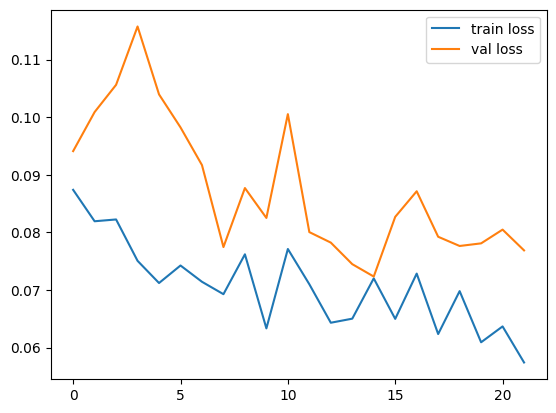

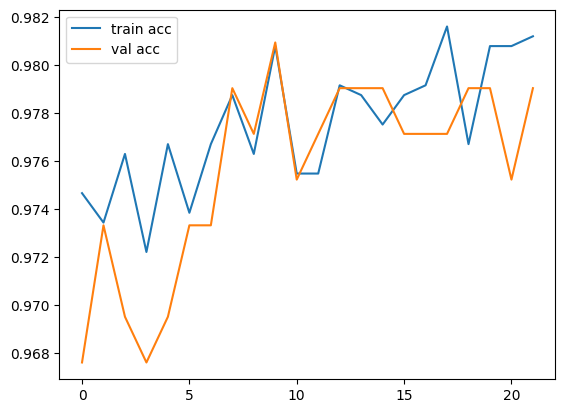

In [19]:
# ====== Plot loss & accuracy ======
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [21]:
# ====== Load best Keras model ======
model = tf.keras.models.load_model('best_model.h5')
print("✅ Loaded best_model.h5 for TFLite conversion")

# ====== Representative dataset generator for INT8 quantization ======
# Use the training data generator to get representative samples
def representative_data_gen():
    for i in range(100):  # Use 100 samples from the training generator
        # Get a batch from the generator and yield a single sample
        X_batch, y_batch = train_gen[i % len(train_gen)] # Cycle through batches
        spec = X_batch[0:1] # Take the first sample from the batch
        yield [spec]

# ====== Convert to TFLite INT8 ======
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

# ====== Save the TFLite model ======
tflite_model_path = "/content/bird_model.tflite" # Explicitly save to /content
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

print(f"✅ INT8 TFLite model saved as {tflite_model_path}, size: {len(tflite_model)} bytes")

✅ Loaded best_model.h5 for TFLite conversion
Saved artifact at '/tmp/tmphx0jj7nx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 63, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133715427353488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133715427353680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133715427352336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133715427355216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133715427355024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133715427354832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133715427354640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133715427351184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133715427354448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133715427356368: TensorSpec(shape=(), dtyp

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ INT8 TFLite model saved as /content/bird_model.tflite, size: 39368 bytes


In [22]:
# Convert the TFLite model to a C header file
!xxd -i bird_model.tflite > bird_model.h

print("✅ TFLite model converted to C header file: bird_model.h")

✅ TFLite model converted to C header file: bird_model.h


In [23]:
# ====== Test the model with random samples ======
import random

# Load the best model
model = tf.keras.models.load_model('best_model.h5')

# Get 5 random indices from the test set
random_indices = random.sample(range(len(paths_test)), 5)

print("Testing with 5 random samples from the test set:")
for i in random_indices:
    file_path = paths_test[i]
    actual_label = y_test[i]
    actual_class = classes[actual_label]

    # Load and preprocess the audio
    y_audio = load_audio(file_path)
    spec = log_mel_spectrogram(y_audio)
    spec = spec[np.newaxis, ..., np.newaxis]  # Add batch and channel dimensions

    # Get the model prediction
    predictions = model.predict(spec, verbose=0)
    predicted_label = np.argmax(predictions[0])
    predicted_class = classes[predicted_label]
    confidence = np.max(predictions[0])

    print(f"\nFile: {file_path}")
    print(f"Actual: {actual_class}")
    print(f"Predicted: {predicted_class}")
    print(f"Confidence: {confidence:.4f}")

Testing with 5 random samples from the test set:

File: /content/drive/MyDrive/iot/Birds/crow/crow_4_part_589.wav
Actual: crow
Predicted: crow
Confidence: 0.9998

File: /content/drive/MyDrive/iot/Birds/sparrow/sparrow_5_part_28.wav
Actual: sparrow
Predicted: sparrow
Confidence: 0.9997

File: /content/drive/MyDrive/iot/Birds/parrot/parrot_6_part_102.wav
Actual: parrot
Predicted: parrot
Confidence: 0.9996

File: /content/drive/MyDrive/iot/Birds/parrot/parrot_6_part_233.wav
Actual: parrot
Predicted: parrot
Confidence: 0.9999

File: /content/drive/MyDrive/iot/Birds/peacock/peacock_1_part_43.wav
Actual: peacock
Predicted: peacock
Confidence: 0.9620
